In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob

import librosa
import librosa.display
import IPython.display as ipd

from itertools import cycle
sns.set_theme(style="white", palette=None)
color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_cycle = cycle(plt.rcParams["axes.prop_cycle"].by_key()["color"])

## Terminology
### Frequency (Hz)
Describes the difference of wavelength.
### Intensity (dB/power)
Describes the amplitude(height) of the wave/ Change intensity -> change loudness.
### Sample rate
Something like "resolution" of the audio (on how many smaller parts the audio wave is divided). Is specific to how the computer reads in the audio file.

## Reading the Audio files

In [2]:
audio_files = glob('../input/ravdess-emotional-speech-audio/*/*.wav')

In [3]:
ipd.Audio(audio_files[7])

## Process audio files

In [4]:
y, sr = librosa.load(audio_files[7])
print(f'y: {y[:10]}')
print(f'shape y: {y.shape}')
print(f'sr : {sr}') # sample rate, default = 22050

y: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
shape y: (79460,)
sr : 22050


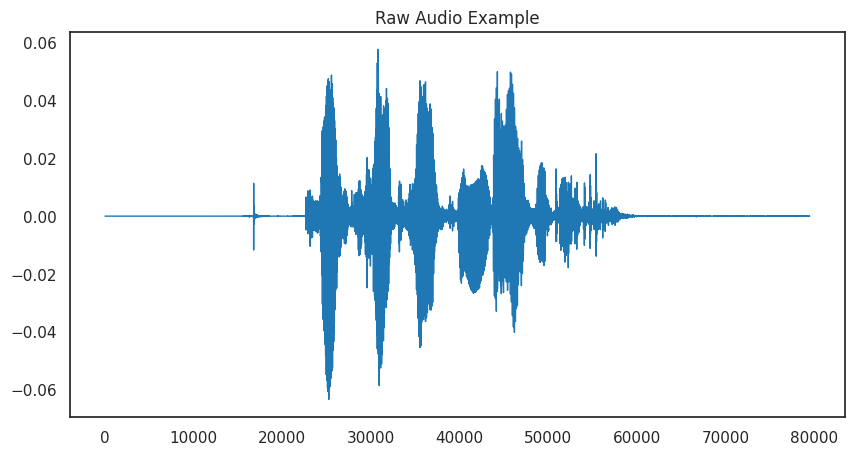

In [5]:
# Plot the data
pd.Series(y).plot(figsize=(10,5),
                  lw=1, # line width
                  title="Raw Audio Example",
                  color=color_pal[0]   
)
plt.show()

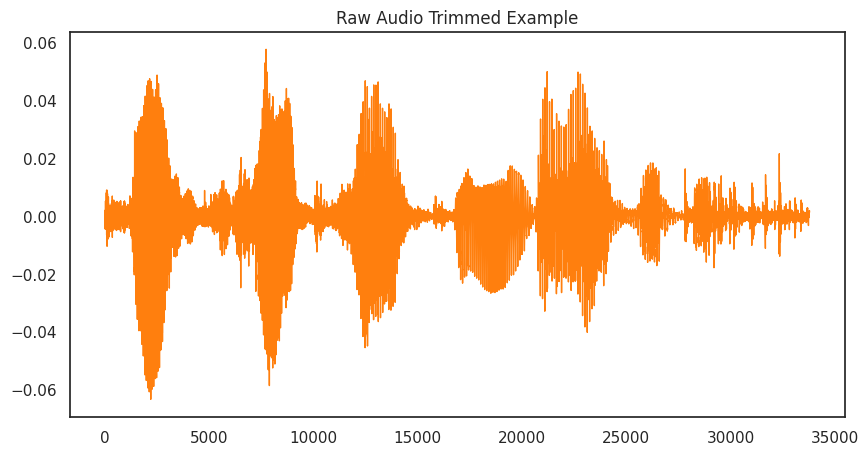

In [6]:
# We have a lot of so call blank spaces(without any sound) at the beginning and at the end of audio
# So we will remove (this info is not helpfull)

# Trimming leading/lagging silence
y_trimmed, _ = librosa.effects.trim(y, top_db=20) # lower than 20 dB - silence and will be trimmed
pd.Series(y_trimmed).plot(figsize=(10, 5),
               lw=1,
               title="Raw Audio Trimmed Example",
               color=color_pal[1]   
)
plt.show()

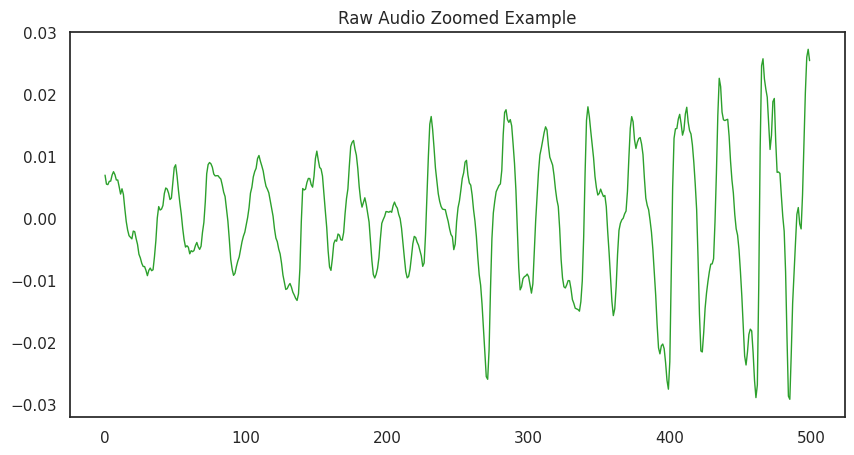

In [7]:
# Let`s zoom in our example to see wave`s shape
pd.Series(y[30000:30500]).plot(figsize=(10, 5),               
               lw=1,
               title="Raw Audio Zoomed Example",
               color=color_pal[2]   
)
plt.show()

## Spectogram

In [8]:
# Use Fuerier - converts a signal from the time domain to the time-frequency domain
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
S_db.shape #(frequency_bins, time_frames) 

(1025, 156)

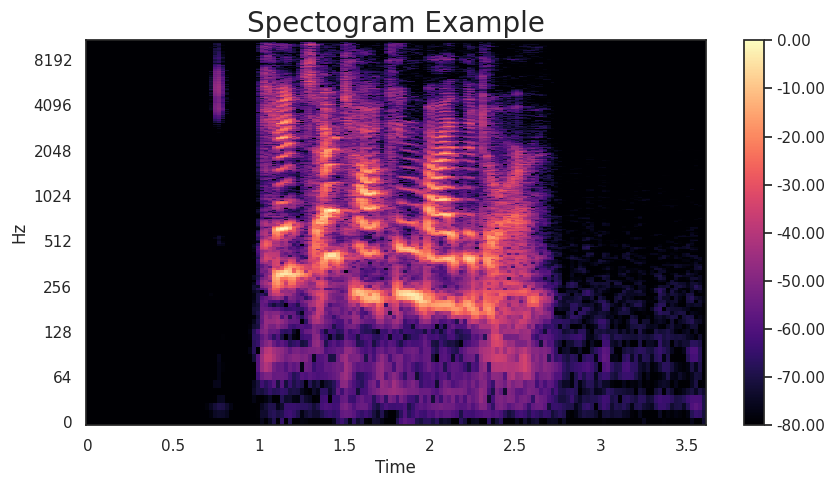

In [10]:
# Plot the transformed audio data
fig, ax = plt.subplots(figsize=(10, 5))
img = librosa.display.specshow(S_db,
                               x_axis='time',
                               y_axis='log',
                               ax=ax   
)
ax.set_title('Spectogram Example', fontsize=20)
fig.colorbar(img, ax=ax, format=f'%0.2f')
plt.show()

## Mel-Spectogram

In [14]:
S = librosa.feature.melspectrogram(y=y,
                                  sr=sr,
                                  n_mels=128 * 2)
S_db_mel = librosa.amplitude_to_db(np.abs(S), ref=np.max)

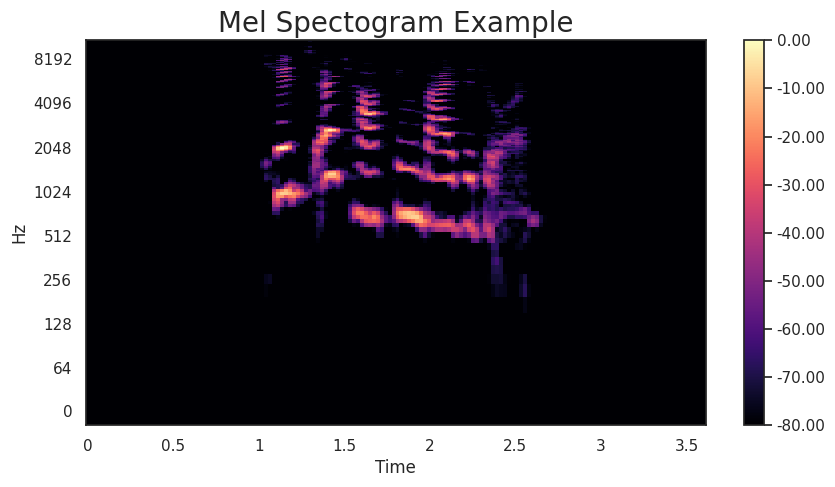

In [15]:
# Plot mel-spectogram
fig, ax = plt.subplots(figsize=(10,5))
img = librosa.display.specshow(S_db_mel,
                              x_axis='time',
                              y_axis='log',
                              ax=ax)
ax.set_title('Mel Spectogram Example', fontsize=20)
fig.colorbar(img, ax=ax, format=f'%0.2f')
plt.show()